In [174]:
install.packages("table1")

Installing package into ‘/home/jupyter/.R/library’
(as ‘lib’ is unspecified)



In [1]:
library(bigrquery)
library(knitr)
library(tidyverse)
library(ggplot2)
library("table1")
library("IRdisplay")
library(grid)
library(gridExtra)
bq_auth()

── Attaching core tidyverse packages ──────────────────────── tidyverse 2.0.0 ──
✔ dplyr     1.1.2     ✔ readr     2.1.4
✔ forcats   1.0.0     ✔ stringr   1.5.0
✔ ggplot2   3.4.4     ✔ tibble    3.2.1
✔ lubridate 1.9.2     ✔ tidyr     1.3.0
✔ purrr     1.0.1     
── Conflicts ────────────────────────────────────────── tidyverse_conflicts() ──
✖ dplyr::filter() masks stats::filter()
✖ dplyr::lag()    masks stats::lag()
ℹ Use the conflicted package (<http://conflicted.r-lib.org/>) to force all conflicts to become errors

Attaching package: ‘table1’


The following objects are masked from ‘package:base’:

    units, units<-



Attaching package: ‘gridExtra’


The following object is masked from ‘package:dplyr’:

    combine




In [2]:
data <-bq_dataset_query(query="
SELECT *

 FROM `yhcr-prd-phm-bia-core.CB_1935_AK.src_bmbc_HVDatafINAL`"
                       ,x="yhcr-prd-phm-bia-core.CB_1935_AK")

HVDatafINAL <- bq_table_download(data) 

In [3]:
 PersonalSocial<-unique(filter(HVDatafINAL,ASQ == "ASQ-3 24 month questionnaire - personal-social score"))

In [4]:
display_jupyter <- function(x) {
  css <- system.file("table1_defaults_1.0/table1_defaults.css", package="table1")
  css <- paste(readLines(css), collapse="\n")
  x <- htmltools::tagList(htmltools::tags$style(css), htmltools::tags$div(class="Rtable1", x))
  IRdisplay::display_html(as.character(x))
}

In [5]:
label(PersonalSocial$event_year)      <- "Year of Measure"
label(PersonalSocial$IMD)      <- "IMD"
label(PersonalSocial$gender_source_value)      <- "Gender"
label( PersonalSocial$ethnic_group)      <- "Ethnic Group"



In [6]:
x1 <-table1(~ PersonalSocial$event_year +  PersonalSocial$gender_source_value + PersonalSocial$ethnic_group+ PersonalSocial$IMD|PersonalSocial$result,data=PersonalSocial
          ,justify=c("left", "left", rep("center", 5)),format_number = TRUE
          ,caption = "COS-EY 4: Social environment-4.1 Family & social relationships"
    
         )

In [8]:
 display_jupyter(x1)

,Child devlopement on schedule(N=6835),Further assesment needed(N=449),Provide learning activities and monitor(N=862),Overall(N=8146)
Year of Measure,,,,
2015,396 (5.8%),21 (4.7%),45 (5.2%),462 (5.7%)
2016,1309 (19.2%),62 (13.8%),159 (18.4%),1530 (18.8%)
2017,1544 (22.6%),81 (18.0%),177 (20.5%),1802 (22.1%)
2018,1879 (27.5%),100 (22.3%),221 (25.6%),2200 (27.0%)
2019,1110 (16.2%),72 (16.0%),141 (16.4%),1323 (16.2%)
2020,271 (4.0%),26 (5.8%),32 (3.7%),329 (4.0%)
2021,158 (2.3%),29 (6.5%),33 (3.8%),220 (2.7%)
2022,115 (1.7%),39 (8.7%),34 (3.9%),188 (2.3%)
2023,53 (0.8%),19 (4.2%),20 (2.3%),92 (1.1%)


In [15]:
OverallTrend1 <- PersonalSocial %>% select(1,8,7)

PersonalSocial1 <- OverallTrend1 %>%
  group_by(event_year,result) 

PS1<- PersonalSocial1 %>% count(result,event_year)


PS1<- group_by(PS1, event_year) %>% mutate(percent = (n/sum(n))*100)


#PS1<-unique(filter(PS1,result =="Child devlopement on schedule" ))

PS1<- group_by(PS1, event_year) %>% mutate(percent = (n/sum(n))*100)
PS1<-unique(filter(PS1,result =="Child devlopement on schedule" ))
#PS1<-unique(filter(PS1,ALevelOutcome == "1. 3 Or More Alevels at A*-B"))




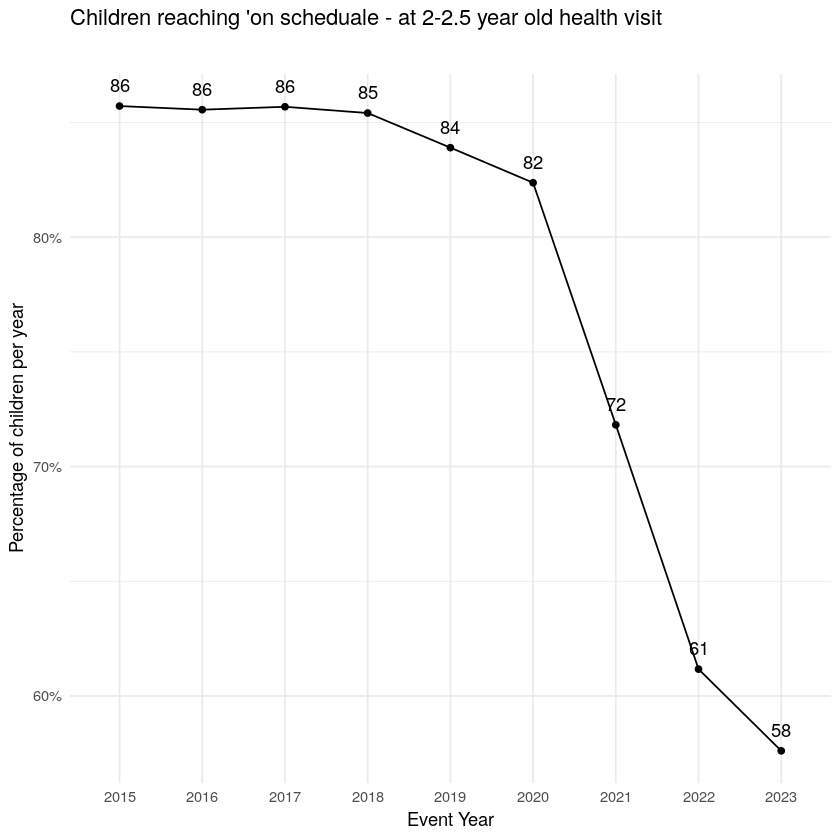

In [22]:
OVERALL<- ggplot(PS1 , aes(x = event_year, y = percent,group = 1)) +
#scale_y_continuous( limits=c(0,1))+
  geom_line() +
  geom_point() +
   ggtitle(expression(atop("Children reaching 'on scheduale - at 2-2.5 year old health visit"))) +


labs(
       x = "Event Year",
       y = "Percentage of children per year") +
scale_y_continuous(labels = function(x) paste0(x, "%"))+
               theme(panel.border = element_blank(),# panel.grid.major = element_blank(),
#panel.grid.minor = element_blank(), 
      axis.line = element_line(colour = "black"),axis.text.x = element_text(angle = 90, vjust = 0.5, hjust=1))+
geom_text(aes(label = round(percent,0)), hjust = 0.5,  vjust = -1) +
                   #+
  theme_minimal()

In [23]:
PersonalSocial

person_id,ethnic_group,gender_source_value,ASQ,numericvalue,IMD,event_year,result
<int>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>
13111453,Unknown,Male,ASQ-3 24 month questionnaire - personal-social score,12,1,2015,Further assesment needed
13537794,Asian or Asian British,Male,ASQ-3 24 month questionnaire - personal-social score,36,6,2019,Provide learning activities and monitor
12613869,Asian or Asian British,Male,ASQ-3 24 month questionnaire - personal-social score,48,1,2016,Child devlopement on schedule
12590423,Asian or Asian British,Male,ASQ-3 24 month questionnaire - personal-social score,54,5,2020,Child devlopement on schedule
12935918,Other ethnic group,Male,ASQ-3 24 month questionnaire - personal-social score,54,1,2016,Child devlopement on schedule
13705266,Asian or Asian British,Female,ASQ-3 24 month questionnaire - personal-social score,36,1,2018,Provide learning activities and monitor
12534858,Asian or Asian British,Female,ASQ-3 24 month questionnaire - personal-social score,42,8,2018,Provide learning activities and monitor
13582476,Asian or Asian British,Male,ASQ-3 24 month questionnaire - personal-social score,42,1,2016,Provide learning activities and monitor
13580057,White,Male,ASQ-3 24 month questionnaire - personal-social score,54,1,2016,Child devlopement on schedule


In [24]:
OverallTrend1 <- PersonalSocial %>% select(1,2,8,7)

PersonalSocial1 <- OverallTrend1 %>%
  group_by(event_year,result,ethnic_group) 

PS1<- PersonalSocial1 %>% count(result,event_year,ethnic_group)


PS1<- group_by(PS1, event_year,ethnic_group) %>% mutate(percent = (n/sum(n))*100)


#PS1<-unique(filter(PS1,result =="Child devlopement on schedule" ))

PS1<- group_by(PS1, event_year,ethnic_group) %>% mutate(percent = (n/sum(n))*100)
PS1<-unique(filter(PS1,result =="Child devlopement on schedule" ))
#PS1<-unique(filter(PS1,ALevelOutcome == "1. 3 Or More Alevels at A*-B"))

In [25]:
PS1

event_year,result,ethnic_group,n,percent
<chr>,<chr>,<chr>,<int>,<dbl>
2015,Child devlopement on schedule,Asian or Asian British,137,88.96104
2015,Child devlopement on schedule,Black or African or Caribbean or Black British,5,83.33333
2015,Child devlopement on schedule,Mixed multiple ethnic groups,25,83.33333
2015,Child devlopement on schedule,Other ethnic group,3,100.00000
2015,Child devlopement on schedule,Unknown,26,81.25000
2015,Child devlopement on schedule,White,200,84.38819
2016,Child devlopement on schedule,Asian or Asian British,488,83.56164
2016,Child devlopement on schedule,Black or African or Caribbean or Black British,21,91.30435
2016,Child devlopement on schedule,Mixed multiple ethnic groups,71,89.87342


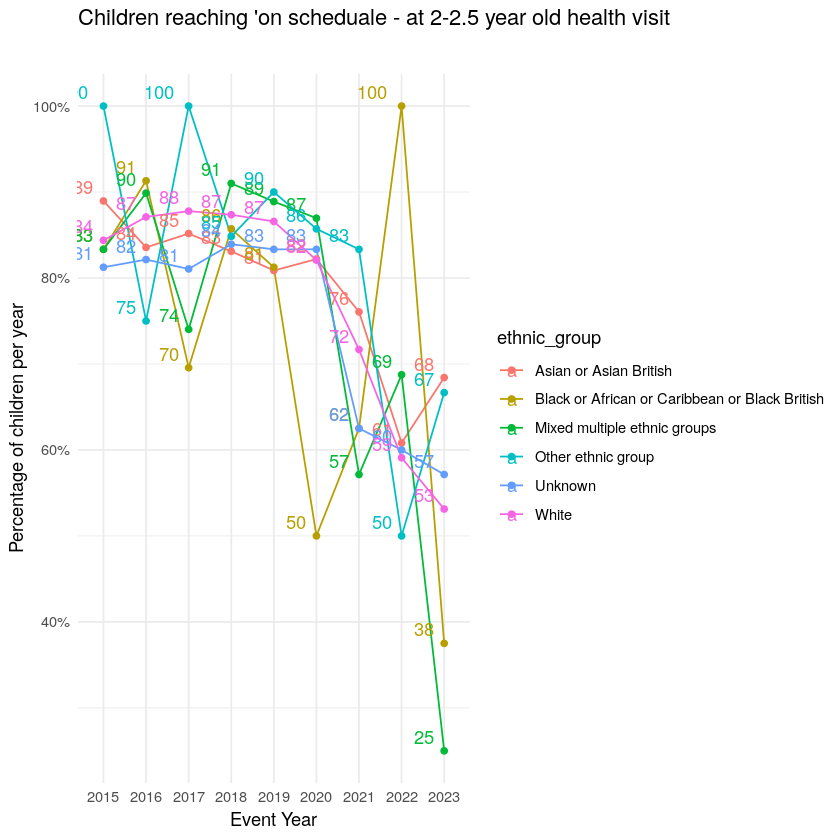

In [31]:
#ethnicity<-
ggplot(PS1 , aes(x = event_year, y = percent,group = ethnic_group,color = ethnic_group)) +
#scale_y_continuous( limits=c(0,1))+
  geom_line() +
  geom_point() +
   ggtitle(expression(atop("Children reaching 'on scheduale - at 2-2.5 year old health visit"))) +


labs(
       x = "Event Year",
       y = "Percentage of children per year") +
scale_y_continuous(labels = function(x) paste0(x, "%"))+
               theme(panel.border = element_blank(),# panel.grid.major = element_blank(),
#panel.grid.minor = element_blank(), 
      axis.line = element_line(colour = "black"),axis.text.x = element_text(angle = 90, vjust = 0.5, hjust=1))+
geom_text(aes(label = round(percent,0)), hjust = 1.5,  vjust = -0.5) +
                   #+
  theme_minimal()